**Project Overview**

This project is based on an experimentation scenario for the casual gaming company “Offline Games – No Wifi Games”. The company was experiencing a decline in revival acceptance rates and meaningful gameplay continuation after players reached the “Game Over” screen.

After analyzing the existing revive flow, it was observed that the current revive screen lacked strong visual hierarchy and behavioral guidance, making players more likely to abandon the session instead of continuing gameplay.

To address this problem, the company decided to conduct a multivariate A/B testing experiment by redesigning the revive screen.

The objective of the experiment was to identify which revive-screen strategy could improve meaningful post-revival gameplay engagement while maintaining a healthy player experience.

**INDEX**

1. [Data Inspection and Cleaning](#data-inspection-and-cleaning)
2. [Descriptive Analysis](#descriptive-analysis)
   - Variant distribution across groups
   - Revival acceptance rate by variant
   - Average additional gameplay minutes by variant
   - Average additional gameplay minutes among revived players
   - Distribution of additional gameplay minutes
3. [Power Analysis](#power-analysis)
4. [Hypothesis Testing](#hypothesis-testing)
   - Chi-Square test of independence for revival acceptance
   - Kruskal-Wallis test for additional gameplay minutes
   - Dunn's post-hoc test for pairwise gameplay comparison
5. [Conclusion](#conclusion)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# required for power analysis
from statsmodels.stats.power import NormalIndPower

# required for chi-square test of independence
from scipy.stats import chi2_contingency

# required for kruskal-wallis test
from scipy.stats import kruskal

# required for dune's test
import scikit_posthocs as sp

## Data Inspection and Cleaning

In [3]:
df = pd.read_excel(r"C:\Users\Rushikesh\Desktop\Projects\AB\data.xlsx")
df.head()

,session_id,variant,clicked_save_me,additional_gameplay_minutes,immediate_post_revival_abandonment,timestamp
0,1,Control,0,0.00,1,2026-01-01 00:01:00
1,2,Control,1,2.00,0,2026-01-01 00:02:00
2,3,Control,0,0.00,1,2026-01-01 00:03:00
3,4,Control,0,0.00,1,2026-01-01 00:04:00
4,5,Control,1,2.73,0,2026-01-01 00:05:00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30092 entries, 0 to 30091
Data columns (total 6 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   session_id                          30092 non-null  int64  
 1   variant                             30092 non-null  object 
 2   clicked_save_me                     30092 non-null  int64  
 3   additional_gameplay_minutes         30092 non-null  float64
 4   immediate_post_revival_abandonment  30092 non-null  int64  
 5   timestamp                           30092 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 1.4+ MB


In [5]:
rename = {'Variant_1_VisualHierarchy': 'Variant_1', 'Variant_2_Emotional': 'Variant_2', 'Variant_3_Urgency': 'Variant_3'}
df['variant'] = df['variant'].replace(rename)
df.head()

,session_id,variant,clicked_save_me,additional_gameplay_minutes,immediate_post_revival_abandonment,timestamp
0,1,Control,0,0.00,1,2026-01-01 00:01:00
1,2,Control,1,2.00,0,2026-01-01 00:02:00
2,3,Control,0,0.00,1,2026-01-01 00:03:00
3,4,Control,0,0.00,1,2026-01-01 00:04:00
4,5,Control,1,2.73,0,2026-01-01 00:05:00


In [6]:
df['variant'].value_counts()

variant
Variant_3    7614
Variant_1    7563
Variant_2    7487
Control      7428
Name: count, dtype: int64

In [7]:
df['clicked_save_me'].value_counts()

clicked_save_me
0    19769
1    10323
Name: count, dtype: int64

## Descriptive Analysis

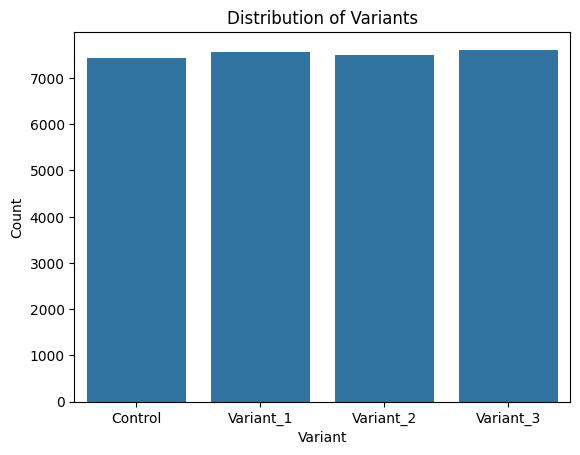

In [8]:
sns.countplot(x='variant', data=df)
plt.title('Distribution of Variants')
plt.xlabel('Variant')
plt.ylabel('Count')
plt.show()

The visualization confirmed that gameplay sessions were distributed consistently across all experimental variants.

Balanced traffic allocation improves experiment reliability and ensures fair comparison between revive-screen strategies.

In [9]:
revival = df.groupby('variant')['clicked_save_me'].mean().mul(100).round(2).reset_index()
revival

,variant,clicked_save_me
0,Control,23.30
1,Variant_1,31.60
2,Variant_2,38.28
3,Variant_3,43.81


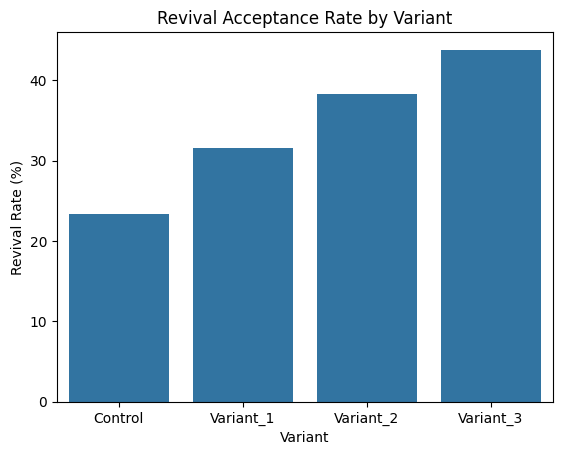

In [10]:
sns.barplot(x='variant', y='clicked_save_me', data=revival)
plt.title('Revival Acceptance Rate by Variant')
plt.xlabel('Variant')
plt.ylabel('Revival Rate (%)')
plt.show()

Revival Acceptance Rate was selected as the primary metric of the experiment.

The metric measured the percentage of players who clicked the “Save Me” CTA after seeing the revive screen.

The analysis showed that:

- the Control group had the lowest revival acceptance rate,
- Variant 1 improved revive discoverability through visual hierarchy optimization,
- Variant 2 further improved player continuation behavior using emotional framing,
- and Variant 3 generated the highest revival acceptance rate through urgency-based messaging.

This suggested that urgency-based interventions were highly effective at driving immediate revive decisions.

In [11]:
gameplay = df.groupby('variant')['additional_gameplay_minutes'].mean().round(2).reset_index()
gameplay

,variant,additional_gameplay_minutes
0,Control,0.49
1,Variant_1,0.94
2,Variant_2,1.95
3,Variant_3,1.18


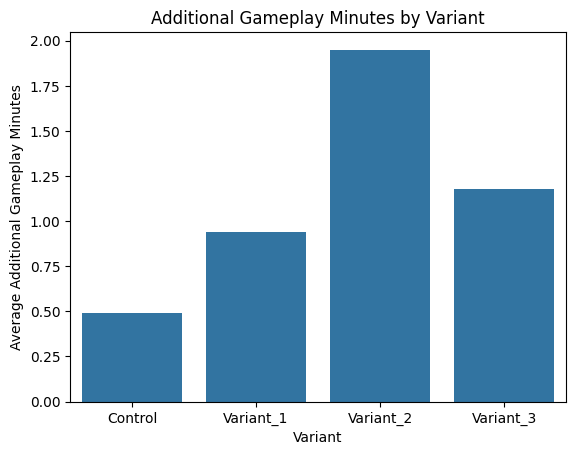

In [12]:
sns.barplot(x='variant', y='additional_gameplay_minutes', data=gameplay)
plt.title('Additional Gameplay Minutes by Variant')
plt.xlabel('Variant')
plt.ylabel('Average Additional Gameplay Minutes')
plt.show()

Average Additional Gameplay Time Per Session was selected as the North Star Metric of the experiment.

This metric measured the average gameplay continuation generated after players encountered the revive screen across all sessions, including players who chose not to revive.

Including all sessions was important because the experiment aimed to measure overall engagement impact rather than only successful revivals.

The analysis showed that:

- Variant 1 moderately improved gameplay continuation,
- Variant 2 generated the strongest gameplay continuation behavior,
- and Variant 3, despite producing the highest revive clicks, generated weaker continuation quality compared to Variant 2.

This indicated that higher conversion rates did not necessarily translate into healthier long-term engagement.

In [13]:
df[df['clicked_save_me']==1].groupby('variant')['additional_gameplay_minutes'].mean().round(2).reset_index()

,variant,additional_gameplay_minutes
0,Control,2.12
1,Variant_1,2.98
2,Variant_2,5.09
3,Variant_3,2.70


Gameplay continuation was also analyzed specifically for players who accepted the revive offer.

This analysis helped evaluate the quality of revived engagement independently from overall revive conversion behavior.

The results showed that players exposed to Variant 2 demonstrated stronger post-revival continuation behavior compared to other variants, indicating that emotional framing generated healthier engagement after revival.

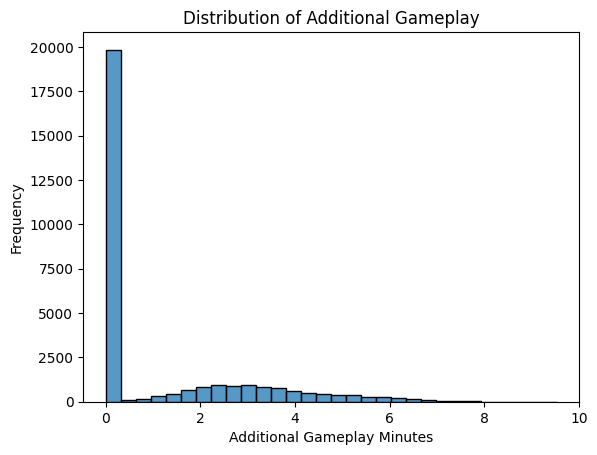

In [14]:
sns.histplot(df['additional_gameplay_minutes'], bins=30)
plt.xlabel("Additional Gameplay Minutes")
plt.ylabel("Frequency")
plt.title("Distribution of Additional Gameplay")
plt.show()

[]

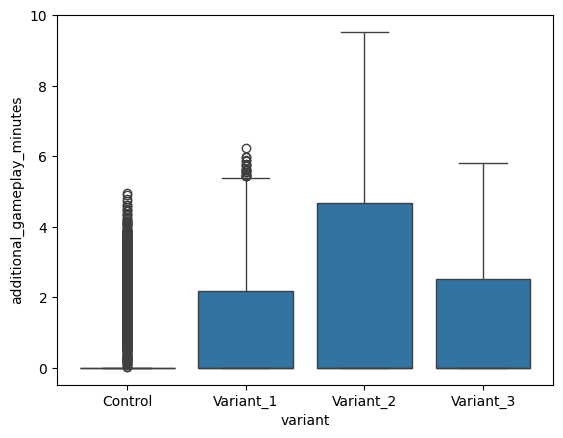

In [15]:
sns.boxplot(
    x='variant',
    y='additional_gameplay_minutes',
    data=df
)

plt.plot()

Before selecting statistical tests, the distribution of additional gameplay time was analyzed.

The gameplay continuation metric exhibited:

- strong right skewness,
- zero inflation,
- and non-normal distribution patterns.

Since the assumptions required for parametric ANOVA testing were violated, non-parametric statistical methods were selected for gameplay continuation analysis.

## Power Analysis

Power analysis was conducted before hypothesis testing to validate whether the sample size was sufficient to detect meaningful behavioral differences between variants.

The analysis helped ensure that the experiment had adequate statistical reliability for comparison across all experimental groups.

In [16]:
baseline = 0.24
expected = 0.29

effect_size = proportion_effectsize(
    baseline,
    expected
)

analysis = NormalIndPower()

sample_size = analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    ratio=1
)

print("Required sample size per group:", round(sample_size))

NameError: name 'proportion_effectsize' is not defined

## Hypothesis Testing

### Chi-Square Test of Independence: Revival Rate

A Chi-Square Test of Independence was conducted to evaluate whether revival acceptance behavior differed significantly across experimental variants.

The test was selected because revival acceptance was a categorical outcome variable.

**Null Hypothesis (H₀):** There is no significant difference in revival acceptance rate across the revive-screen variants.

**Alternative Hypothesis (H₁):** There is a significant difference in revival acceptance rate across the revive-screen variants.

In [ ]:
contingency_table = pd.crosstab(
    df['variant'],
    df['clicked_save_me']
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p)

Chi-square statistic: 781.4119202210169
P-value: 4.650421026261949e-169


The Chi-Square test produced a statistically significant result (p < 0.05), indicating that revival acceptance behavior differed significantly across revive-screen variants.

This confirmed that player revival decisions were influenced by revive-screen design changes introduced during the experiment.

### Kruskal Wallis Test: Additional Gameplay Minutes

A Kruskal-Wallis Test was conducted to compare gameplay continuation distributions across the four experimental groups.

A non-parametric test was selected because gameplay continuation data violated normality assumptions required for ANOVA testing.

**Null Hypothesis (H₀):** The distribution of additional gameplay time is the same across all revive-screen variants.

**Alternative Hypothesis (H₁):** At least one revive-screen variant has a significantly different gameplay continuation distribution compared to the others.

In [ ]:
control = df[df['variant']=='Control']['additional_gameplay_minutes']
v1 = df[df['variant']=='Variant_1']['additional_gameplay_minutes']
v2 = df[df['variant']=='Variant_2']['additional_gameplay_minutes']
v3 = df[df['variant']=='Variant_3']['additional_gameplay_minutes']

stat, p = kruskal(control, v1, v2, v3)

print("Kruskal Statistic:", stat)
print("P-value:", p)

Kruskal Statistic: 1348.6451421923955
P-value: 4.098631968987557e-292


The Kruskal-Wallis test indicated statistically significant differences in gameplay continuation behavior between variants.

This suggested that revive-screen design changes had a measurable impact on meaningful gameplay continuation.

### Dunn's Test: Post Hoc Analysis

Since the Kruskal-Wallis Test only confirmed the existence of significant differences between groups, Dunn’s Post-Hoc Test was conducted to identify which specific variants differed significantly from each other.

**Null Hypothesis (H₀):** There is no significant difference in gameplay continuation between a pair of revive-screen variants.

**Alternative Hypothesis (H₁):** There is a significant difference in gameplay continuation between a pair of revive-screen variants.

In [ ]:
dunn_test = sp.posthoc_dunn(
    df,
    val_col='additional_gameplay_minutes',
    group_col='variant',
    p_adjust='bonferroni'
)

print(dunn_test)

                 Control     Variant_1      Variant_2      Variant_3
Control     1.000000e+00  1.691743e-44  3.537779e-257  1.447081e-153
Variant_1   1.691743e-44  1.000000e+00   5.811621e-91   2.084109e-34
Variant_2  3.537779e-257  5.811621e-91   1.000000e+00   7.340829e-15
Variant_3  1.447081e-153  2.084109e-34   7.340829e-15   1.000000e+00


The pairwise comparison results showed extremely small p-values (p < 0.05) across all variant combinations, indicating statistically significant differences between every experimental group.

Key findings from the analysis:

- Variant 1 significantly improved gameplay continuation compared to the Control group, suggesting that better visual hierarchy positively influenced player continuation behavior.
- Variant 2 significantly outperformed all other variants, indicating that emotional framing generated the strongest meaningful gameplay continuation.
- Variant 3 also significantly differed from the other groups, confirming that urgency-based messaging influenced player behavior differently from both visual hierarchy and emotional framing approaches.

## Conclusion

This experiment evaluated how different behavioral revive-screen strategies influenced player revival decisions and meaningful gameplay continuation in a casual mobile gaming environment.

The analysis revealed that revive-screen design had a statistically significant impact on both **revival acceptance behavior and gameplay continuation outcomes.**

Key findings from the experiment showed that:

- Variant 3 (Urgency-Based Messaging) generated the highest revival acceptance rate at **43.81%**, demonstrating that urgency and scarcity mechanics were highly effective at driving immediate player actions.
- Variant 2 (Emotional Framing) produced the strongest gameplay continuation behavior, generating an average of **1.95** additional gameplay minutes per session and outperforming all other experimental groups in meaningful engagement quality.
- Variant 1 (Visual Hierarchy Optimization) improved revival acceptance compared to the Control group, confirming that stronger CTA visibility positively influenced player decision-making.

Statistical testing further confirmed that the observed differences between variants were statistically significant:

- Chi-Square Test identified significant differences in revival acceptance behavior across variants.
- Kruskal-Wallis Test confirmed significant differences in gameplay continuation distributions.
- Dunn’s Post-Hoc Test identified significant pairwise behavioral differences between experimental groups.

The experiment also demonstrated an important product insight, **higher revive conversions did not necessarily translate into healthier long-term engagement.**

Although urgency-based messaging generated the highest revive clicks, emotionally-driven behavioral interventions produced stronger sustainable gameplay continuation and healthier player engagement overall.

Based on the findings, **Variant 2 (Emotional Framing)** is recommended as the optimal revive-screen strategy because it achieved the best balance between player continuation behavior, engagement quality, and overall gameplay experience.